In [ ]:
import pandas as pd
import numpy as np
import pyarrow
from sklearn.model_selection import  train_test_split
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras import optimizers
import keras
import tensorflow as tf
from src import *
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping


# Configurações 
print(tf.config.list_physical_devices())
BATCH_SIZE = 4096

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **Classificação para 3 classes**

#### Função para encontrar o número máximo de neurônio

In [1]:
def num_max_neuronio(X, d):
    CT = len(X)
    return int((CT - 10)/(10 * (d + 2)))

#### Leitura dos dados e adaptações necessárias para a rede neural 

In [3]:
colunas = (
        [f'questao_{i}_LC' for i in range(1, 46)] +
        [f'questao_{i}_CH' for i in range(1, 46)] +
        [f'questao_{i}_CN' for i in range(1, 46)] +
        [f'questao_{i}_MT' for i in range(1, 46)] +
        ['NU_ANO', 'NU_NOTA_LC', 'NU_NOTA_CH', 'NU_NOTA_CN', 'NU_NOTA_MT']
    )
df = pd.read_parquet('data/dados acertos/')

In [4]:
df = calcular_acertos_por_area(df)

In [5]:
df['MEDIA_GERAL'] = (
    df['ACERTOS_LC'] + 
    df['ACERTOS_MT'] + 
    df['ACERTOS_CH'] + 
    df['ACERTOS_CN']
) / 4

df['CLASSE'] = df.groupby('NU_ANO')['MEDIA_GERAL'].transform(
    lambda x: pd.qcut(x, q=3, labels=[0, 1, 2])
).astype('Int64')

df['CLASSE'] = df['CLASSE'].astype(int)

In [6]:
features = (
        [f'questao_{i}_LC' for i in range(1, 46)] +
        [f'questao_{i}_CH' for i in range(1, 46)] +
        [f'questao_{i}_CN' for i in range(1, 46)] +
        [f'questao_{i}_MT' for i in range(1, 46)] 
    )

X = df[features]
y = df['CLASSE']


#### Separando os dados

In [7]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

#### Normalizando os dados

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train).astype(np.float32)
x_val   = scaler.transform(x_val).astype(np.float32)
x_test  = scaler.transform(x_test).astype(np.float32)

In [9]:
# Analisando os dados do rotulo de treinamento
print("Tipo:", y_train.dtype)
print("Valores únicos:", np.unique(y_train))
print("Amostra:", y_train[:10])

Tipo: int64
Valores únicos: [0 1 2]
Amostra: 5746145    1
3123285    0
2370770    2
1514602    2
1213255    0
4628834    1
216790     1
2065521    0
2661903    2
4442373    1
Name: CLASSE, dtype: int64


#### Construindo a rede neural

In [23]:
max_neurons = num_max_neuronio(x_train, d = X.shape[1])
print("Número máximo de neurônios:", max_neurons)

Número máximo de neurônios: 4765


#### Rede com **1** camada 

In [ ]:
model = Sequential()

model.add(Dense(4762, input_dim=X.shape[1],
                kernel_initializer='normal',
                activation='relu'))

model.add(Dense(3, kernel_initializer='normal', activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', mode='min', patience=10, verbose=1)

model.summary()

/Users/sergioo/Documents/GitHub/Projeto_ENEM/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 4762)           │       861,922 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │        14,289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 876,211 (3.34 MB)

 Trainable params: 876,211 (3.34 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size= BATCH_SIZE,
    validation_data= (x_val, y_val),
    callbacks=[es],
    verbose=1
)

Epoch 1/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - accuracy: 0.8951 - loss: 0.2813 - val_accuracy: 0.9181 - val_loss: 0.1844
Epoch 2/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 78s 37ms/step - accuracy: 0.9136 - loss: 0.1993 - val_accuracy: 0.9123 - val_loss: 0.2031
Epoch 3/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 78s 37ms/step - accuracy: 0.9115 - loss: 0.2103 - val_accuracy: 0.9163 - val_loss: 0.1961
Epoch 4/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 79s 37ms/step - accuracy: 0.9087 - loss: 0.2258 - val_accuracy: 0.9109 - val_loss: 0.2213
Epoch 5/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 79s 37ms/step - accuracy: 0.9074 - loss: 0.2365 - val_accuracy: 0.9088 - val_loss: 0.2263


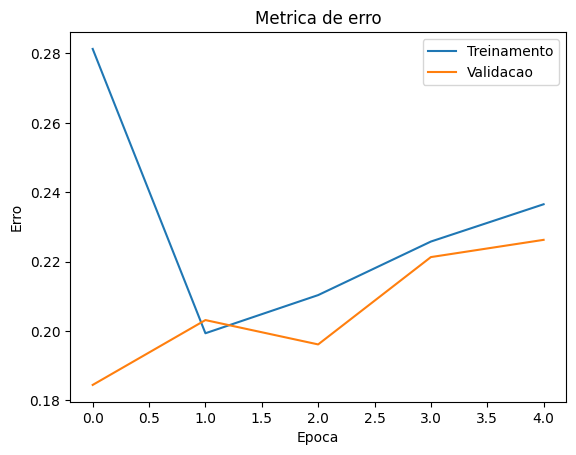

--> E_val - E_in = -0.0007
--> Acuracia (treino): 0.9086
--> Acuracia (validacao): 0.9088
--> acc_train - acc_val = -0.0002


In [29]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(x_train, y_train, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de validacao
E_val, acc_val = model.evaluate(x_val, y_val, batch_size=BATCH_SIZE, verbose=0)

print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")

#### Rede com 2 camadas

In [35]:
model = Sequential()
model.add(Input(shape=(x_train.shape[1],)))


model.add(Dense(2381,kernel_initializer='normal',activation='relu'))

# Dividi por 2 até que a quantidade de parametros * 10 seja menor que o número de amostras
model.add(Dense(148, kernel_initializer='normal', activation='relu'))

model.add(Dense(3, kernel_initializer='normal', activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', mode='min', patience=10, verbose=1)

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 2381)           │       430,961 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 148)            │       352,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │           447 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 783,944 (2.99 MB)

 Trainable params: 783,944 (2.99 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size= BATCH_SIZE,
    validation_data= (x_val, y_val),
    callbacks=[es],
    verbose=1
)

Epoch 1/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 70s 32ms/step - accuracy: 0.8373 - loss: 0.6377 - val_accuracy: 0.7898 - val_loss: 1.9896
Epoch 2/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 67s 31ms/step - accuracy: 0.8404 - loss: 2.0177 - val_accuracy: 0.8713 - val_loss: 1.4618
Epoch 3/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 69s 33ms/step - accuracy: 0.8442 - loss: 4.0043 - val_accuracy: 0.7778 - val_loss: 11.8462
Epoch 4/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 68s 32ms/step - accuracy: 0.8441 - loss: 6.8713 - val_accuracy: 0.8629 - val_loss: 5.8013
Epoch 5/5
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 70s 33ms/step - accuracy: 0.8424 - loss: 10.3885 - val_accuracy: 0.9028 - val_loss: 3.1520


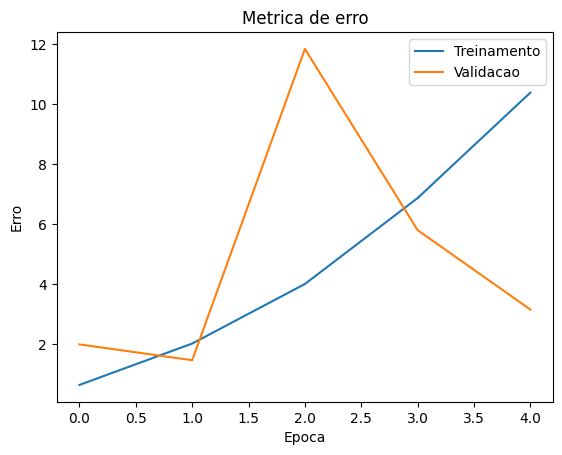

--> E_val - E_in = -0.0022
--> Acuracia (treino): 0.9027
--> Acuracia (validacao): 0.9028
--> acc_train - acc_val = -0.0001


In [37]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(x_train, y_train, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de validacao
E_val, acc_val = model.evaluate(x_val, y_val, batch_size=BATCH_SIZE, verbose=0)

print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")

#### Rede forçando overfitting

In [ ]:

model = Sequential()

model.add(Dense(100, input_dim=180,
                kernel_initializer='he_normal',
                
                activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(100, kernel_initializer='he_normal',
                
                activation='relu'))
#model.add(Dropout(0.2))

# Camada de saída
model.add(Dense(9, kernel_initializer='he_normal', activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', mode='min', patience=10, verbose=1)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[es],
    verbose=1
)